In [ ]:
from google.colab import drive, userdata

drive.mount('/content/drive')

GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")

%cd /content
!git clone https://{GITHUB_TOKEN}@github.com/Bassey-data/Auto-insurance-claim-frequency.git

%cd /content/Auto-insurance-claim-frequency
!git config user.email "basseysamuel404@gmail.com"
!git config user.name "Bassey-data"
!git remote set-url origin https://{GITHUB_TOKEN}@github.com/Bassey-data/Auto-insurance-claim-frequency.git
!git checkout feature/glm-modeling

print("Setup complete")

Mounted at /content/drive
/content
Cloning into 'Auto-insurance-claim-frequency'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 67 (delta 28), reused 36 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (67/67), 470.59 KiB | 9.80 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/Auto-insurance-claim-frequency
Branch 'feature/glm-modeling' set up to track remote branch 'feature/glm-modeling' from 'origin'.
Switched to a new branch 'feature/glm-modeling'
Setup complete


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_poisson_deviance
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print("Imports OK")

Imports OK


In [ ]:
def parse_arff(path):
    columns = []
    data_start = None

    with open(path, "r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped.lower().startswith("@attribute"):
            parts = stripped.split(maxsplit=2)
            columns.append(parts[1])
        elif stripped.lower().startswith("@data"):
            data_start = i + 1
            break

    data_lines = [l.strip() for l in lines[data_start:] if l.strip()]

    rows = []
    for line in data_lines:
        values = [v.strip().strip("'").strip('"') for v in line.split(",")]
        rows.append(values)

    return pd.DataFrame(rows, columns=columns)

In [ ]:
def prepare_data():
    from sklearn.model_selection import train_test_split

    # Load or regenerate base parquet
    parquet_path = "data/processed/freMTPL2freq.parquet"
    if os.path.exists(parquet_path):
        df = pd.read_parquet(parquet_path)
    else:
        df = parse_arff("/content/drive/MyDrive/ACQsci.arff")
        df_converted = df.apply(pd.to_numeric, errors="ignore")
        for col in df_converted.select_dtypes(include="object").columns:
            df_converted[col] = df_converted[col].astype("category")
        df = df_converted
        os.makedirs("data/processed", exist_ok=True)
        df.to_parquet(parquet_path, index=False)

    # Apply caps
    df["VehAge"] = df["VehAge"].clip(upper=20)
    df["Exposure"] = df["Exposure"].clip(upper=1)
    df["ClaimNb"] = df["ClaimNb"].clip(upper=4)

    # Area ordinal encoding
    area_order = sorted(df["Area"].cat.categories)
    area_map = {cat: i for i, cat in enumerate(area_order)}
    df["Area_ord"] = df["Area"].map(area_map).astype(int)

    # Train/test split
    nominal_cols = ["VehBrand", "VehGas", "Region"]
    df["had_claim"] = (df["ClaimNb"] > 0).astype(int)
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["had_claim"])
    train_df = train_df.drop(columns="had_claim")
    test_df = test_df.drop(columns="had_claim")

    # GLM feature sets
    train_glm = pd.get_dummies(train_df, columns=nominal_cols, drop_first=True)
    test_glm = pd.get_dummies(test_df, columns=nominal_cols, drop_first=True)
    train_glm, test_glm = train_glm.align(test_glm, join="left", axis=1, fill_value=0)
    train_glm = train_glm.drop(columns="Area")
    test_glm = test_glm.drop(columns="Area")

    # Save
    os.makedirs("data/processed", exist_ok=True)
    train_glm.to_parquet("data/processed/train_glm.parquet", index=False)
    test_glm.to_parquet("data/processed/test_glm.parquet", index=False)

    print("Data ready")
    return train_glm, test_glm


# Check if files exist, regenerate if not
if not os.path.exists("data/processed/train_glm.parquet"):
    train, test = prepare_data()
else:
    train = pd.read_parquet("data/processed/train_glm.parquet")
    test = pd.read_parquet("data/processed/test_glm.parquet")
    print("Loaded from parquet")

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")

Data ready
Train: (542410, 41)
Test:  (135603, 41)


In [ ]:
# All columns except ID, target and offset are features
feature_cols = [c for c in train.columns if c not in ("IDpol", "ClaimNb", "Exposure")]

X_train = train[feature_cols].astype(float)
y_train = train["ClaimNb"]
offset_train = np.log(train["Exposure"])

X_test = test[feature_cols].astype(float)
y_test = test["ClaimNb"]
offset_test = np.log(test["Exposure"])

print(f"X_train shape: {X_train.shape}")
print(f"Offset range: {offset_train.min():.2f} to {offset_train.max():.2f}")

X_train shape: (542410, 38)
Offset range: -5.90 to 0.00


In [ ]:
# Add constant column for the intercept term
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test, has_constant="add")

# Fit Poisson GLM with log link and exposure offset
glm_model = sm.GLM(
    y_train,
    X_train_sm,
    family=sm.families.Poisson(),
    offset=offset_train
)

glm_result = glm_model.fit()
print(glm_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542371
Model Family:                 Poisson   Df Model:                           38
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1444e+05
Date:                Thu, 09 Jul 2026   Deviance:                   1.7344e+05
Time:                        08:16:52   Pearson chi2:                 1.39e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01068
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -3.9787      0.051    -77.

In [ ]:
# Generate predictions
train_pred = glm_result.predict(X_train_sm, offset=offset_train)
test_pred = glm_result.predict(X_test_sm, offset=offset_test)

# Naive baseline, same frequency for every policy
naive_freq = y_train.sum() / train["Exposure"].sum()
naive_pred_test = naive_freq * test["Exposure"]

# Poisson deviance
train_deviance = mean_poisson_deviance(y_train, train_pred)
test_deviance = mean_poisson_deviance(y_test, test_pred)
naive_deviance = mean_poisson_deviance(y_test, naive_pred_test)

print(f"Naive baseline test deviance: {naive_deviance:.4f}")
print(f"GLM train deviance:           {train_deviance:.4f}")
print(f"GLM test deviance:            {test_deviance:.4f}")
print()
improvement = (1 - test_deviance / naive_deviance) * 100
print(f"GLM improves on naive baseline by {improvement:.1f}%")

Naive baseline test deviance: 0.3294
GLM train deviance:           0.3198
GLM test deviance:            0.3191

GLM improves on naive baseline by 3.1%


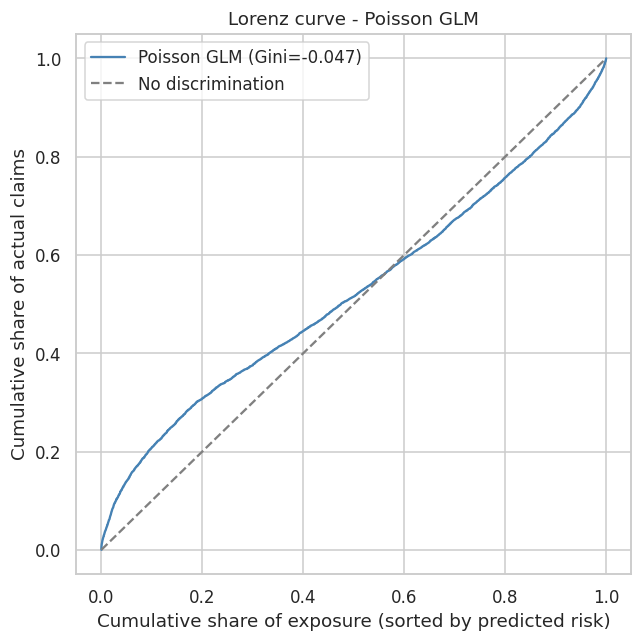

Gini index: -0.0473


In [ ]:
def lorenz_curve(y_true, y_pred, exposure):
    order = np.argsort(y_pred)
    y_true_sorted = np.array(y_true)[order]
    exposure_sorted = np.array(exposure)[order]
    cum_exposure = np.cumsum(exposure_sorted) / exposure_sorted.sum()
    cum_claims = np.cumsum(y_true_sorted) / y_true_sorted.sum()
    return cum_exposure, cum_claims

def gini_index(cum_exposure, cum_claims):
    return 1 - 2 * np.trapezoid(cum_claims, cum_exposure)

cum_exp_glm, cum_claims_glm = lorenz_curve(y_test, test_pred, test["Exposure"])
gini_glm = gini_index(cum_exp_glm, cum_claims_glm)

plt.figure(figsize=(6, 6))
plt.plot(cum_exp_glm, cum_claims_glm, label=f"Poisson GLM (Gini={gini_glm:.3f})", color="steelblue")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="No discrimination")
plt.xlabel("Cumulative share of exposure (sorted by predicted risk)")
plt.ylabel("Cumulative share of actual claims")
plt.title("Lorenz curve - Poisson GLM")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Gini index: {gini_glm:.4f}")

In [ ]:
# Save results to reports folder for later comparison with LightGBM
os.makedirs("reports", exist_ok=True)

glm_results = {
    "model": "Poisson GLM",
    "naive_deviance": float(naive_deviance),
    "test_deviance": float(test_deviance),
    "gini": float(gini_glm)
}

with open("reports/glm_results.json", "w") as f:
    json.dump(glm_results, f, indent=2)

print(glm_results)

{'model': 'Poisson GLM', 'naive_deviance': 0.3293952656959494, 'test_deviance': 0.3191445621187486, 'gini': -0.047309252098169274}


In [11]:
%cd /content/Auto-insurance-claim-frequency
!cp "/content/drive/MyDrive/04_glm_modeling.ipynb" notebooks/04_glm_modeling.ipynb
!git add notebooks/04_glm_modeling.ipynb
!git commit -m "Fix GLM notebook - clean standalone version"
!git push origin main

/content/Auto-insurance-claim-frequency
cp: cannot stat '/content/drive/MyDrive/04_glm_modeling.ipynb': No such file or directory
On branch feature/glm-modeling
Your branch is up to date with 'origin/feature/glm-modeling'.

nothing to commit, working tree clean
Everything up-to-date
